In [2]:
#other
import os
import numpy as np
import pandas as pd
import pickle as pkl
from copy import deepcopy
import matplotlib.pyplot as plt
from runs import multi_subject_experiments
from utils_multisubject import read_files, create_window_df
from imblearn.over_sampling import SMOTE, KMeansSMOTE, BorderlineSMOTE


#sklearn
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error, r2_score, f1_score, classification_report
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.utils import shuffle

loaded = False
experiment_number = 3

### Experiment Set-Up

### Setup
Identify the fNIRS data source folder, determine which experiment set to run, and calculate the window length.

In [3]:
randomness_test = False
save_model_results = False

finetuning_test_size = 0.3
test_size = 0.2
shuffle_data = True

# Chosen Experiment from runs.py
random_state = 42

# Window Set Up
seconds = 8 #Duration of each window in seconds

window_size = int(seconds*5.2) #Calculating window size from fnirs frame rate

# Source Folders
source_folder = "/Users/juliasantaniello/Desktop/fNIRS-2-RL/Experiment/ParticipantData/fNIRS/LabeledData"

# Channels Used
channels = ["L_O_DSphi", "L_D_DSphi", "R_D_DSphi", "R_O_DSphi",	"L_O_DSI",	"R_D_DSI",	"R_O_DSI",	"L_D_DSI"]

# Label Mapping
labels_for_windows = ["discrete_optimal", "binary_optimal", "continuous_optimal"]

# Load Training List and Conditions from runs.py
participant_list, conditions_list, experiment_name = multi_subject_experiments[experiment_number].values()

# List of Participants and Conditions Used in Training
participants = str(participant_list).replace("'", "")
conditions = str(conditions_list)[2:-2].replace("'", "")

print("Experiment Name: ", experiment_name)
print("\nTraining List: ", participants, "\nTraining Conditions: ", conditions) 

Experiment Name:  multiSubject

Training List:  [3, 5, 6, 7, 8, 10, 12, 20, 23, 24, 25] 
Training Conditions:  LW


In [3]:
if not loaded:
    # Read Files for Training Data
    all_data = read_files(participant_list=participant_list, source_folder_1 = source_folder, conditions=conditions_list)

    df_data_all = pd.DataFrame()
    df_labels_all = pd.DataFrame()
    

    #Create Windows
    for key in all_data.keys():
        window_data, window_labels = create_window_df(all_data[key], window_size=window_size, step_size=1, labels=labels_for_windows, features=channels)
        window_data["Key"] = key
        window_labels["Key"] = key
        print(key, "is done")
        df_data_all = pd.concat([df_data_all, window_data], ignore_index=True)
        df_labels_all = pd.concat([df_labels_all, window_labels], ignore_index=True)

    df_data_all.drop(columns=["start_timestamp", "end_timestamp"], inplace=True)

    loaded = True

007_LW_LabeledData.csv
024_LW_LabeledData.csv
012_LW_LabeledData.csv
010_LW_LabeledData.csv
020_LW_LabeledData.csv
023_LW_LabeledData.csv
003_LW_LabeledData.csv
005_LW_LabeledData.csv
008_LW_LabeledData.csv
025_LW_LabeledData.csv
006_LW_LabeledData.csv
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
007LW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
024LW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
012LW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
010LW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
020LW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
023LW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
003LW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
005LW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
008LW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
025LW is do

In [ ]:
name = "MLP"


# binary_classifer = RandomForestClassifier(max_depth=4, n_estimators=30, random_state=random_state)
# multiclass_classifer = RandomForestClassifier(max_depth=5, n_estimators=30, random_state=random_state)
# regressor= RandomForestRegressor(max_depth=8, n_estimators=30, random_state=random_state)

binary_classifier = MLPClassifier(
        hidden_layer_sizes=(8, 3),      # Reduce model complexity
        activation='logistic',
        solver='adam',
        alpha=0.05,                       # Increase regularization
        batch_size=216,                   # Larger batch size for stability
        learning_rate_init=0.0015,         # Lower initial learning rate
        learning_rate='adaptive',
        max_iter=150,                     # Fewer epochs to prevent overfitting
        early_stopping=True,
        validation_fraction=0.2,          # More validation data for early stopping
        n_iter_no_change=10,              # Stop earlier if no improvement
        random_state=random_state)
 
#     # "RandomForest": RandomForestClassifier(max_depth=4, n_estimators=30, random_state=random_state),
#     # "DecisionTree": DecisionTreeClassifier(max_depth=4, random_state=random_state), 
#     # "KNN": KNeighborsClassifier(),          
#     # "SVM": SVC()



multiclass_classifier = MLPClassifier(
        hidden_layer_sizes=(10, 3),      # Reduce model complexity
        activation='logistic',
        solver='adam',
        alpha=0.05,                       # Increase regularization
        batch_size=148,                   # Larger batch size for stability
        learning_rate_init=0.0015,         # Lower initial learning rate
        learning_rate='adaptive',
        max_iter=150,                     # Fewer epochs to prevent overfitting
        early_stopping=True,
        validation_fraction=0.2,          # More validation data for early stopping
        n_iter_no_change=10,              # Stop earlier if no improvement
        random_state=random_state)
 
#     # "RandomForest": RandomForestClassifier(max_depth=5, n_estimators=30, random_state=random_state),
#     # "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=random_state), 
#     # "KNN": KNeighborsClassifier(),          
#     # "SVM": SVC()


regressor_model = MLPRegressor(
        hidden_layer_sizes=(16, 3),      # Reduce model complexity
        activation='logistic',
        solver='adam',
        alpha=0.06,                       # Increase regularization
        batch_size=256,                   # Larger batch size for stability
        learning_rate_init=0.0015,         # Lower initial learning rate
        learning_rate='adaptive',
        max_iter=200,                     # Fewer epochs to prevent overfitting
        early_stopping=True,
        validation_fraction=0.2,          # More validation data for early stopping
        n_iter_no_change=10,              # Stop earlier if no improvement
        random_state=random_state)
 
#     # "RandomForest": RandomForestClassifier(max_depth=8, n_estimators=30, random_state=random_state),
#     # "DecisionTree": DecisionTreeClassifier(max_depth=8, random_state=random_state), 
#     # "KNN": KNeighborsClassifier(),          
#     # "SVM": SVC()

# if randomness_test:
#     save_model_results = False

NameError: name 'RandomForestClassifier' is not defined

### Determining Cross-Participant Validation Set
Exclude ~20% of participants in the same condition to cross-validate the model after training.

In [70]:
# Randomly Remove 1/5 of Participants for Cross-Validation

number_of_participants = len(participant_list)

number_of_participants_for_validation = number_of_participants // 5

random_indices = np.random.choice(number_of_participants, number_of_participants_for_validation, replace=False)

train_participants = [participant_list[i] for i in range(number_of_participants) if i not in random_indices]
validation_participants = [participant_list[i] for i in random_indices]

print("Validation Participants: ", validation_participants)
print("Training Participants: ", train_participants)


Validation Participants:  [3, 8]
Training Participants:  [5, 6, 7, 10, 12, 20, 23, 24, 25]


### Import Training and Validation Data for Window Creation


In [71]:
for p in validation_participants:
    p_key = "00{}".format(p)
    if len(p_key)>3:
        p_key = p_key[1:]
    final_key = p_key+conditions

    validation_data = df_data_all[df_data_all["Key"]==final_key]
    validation_labels = df_labels_all[df_labels_all["Key"]==final_key]

    training_data = df_data_all[df_data_all["Key"]!= final_key]
    training_labels = df_labels_all[df_labels_all["Key"]!=final_key]


df_data_val = validation_data.drop(columns=["Key"])
df_labels_val = validation_labels.drop(columns=["Key"])

df_data_train = training_data.drop(columns=["Key"])
df_labels_train = training_labels.drop(columns=["Key"])


df_labels_val["discrete_label"].value_counts()

discrete_label
0    855
1     89
2     64
Name: count, dtype: int64

### Separate Data into Inputs and Labels

In [72]:
def create_train_data(df_data, df_labels, finetune=False):
    
    df = pd.concat([df_data.reset_index(drop=True), df_labels.reset_index(drop=True)], axis=1)
    
    min_discrete = int(df['discrete_label'].value_counts().min())
    df_balanced_discrete = df.groupby('discrete_label', group_keys=False).apply(lambda x: x.sample(min_discrete, random_state=random_state, replace=False))

    # Downsample binary labels
    min_binary = int(df['binary_label'].value_counts().min())
    print("Minimum count for binary_label:", min_binary)
    df_balanced_binary = df.groupby('binary_label', group_keys=False).apply(lambda x: x.sample(min_binary, random_state=random_state, replace=False))

    # Separate features and labels
    X_binary = df_balanced_binary[df_data.columns]
    X_discrete = df_balanced_discrete[df_data.columns]
    X_continuous = df_data[df_data.columns]

    y_discrete = df_balanced_discrete['discrete_label']
    y_binary = df_balanced_binary['binary_label']
    y_continuous = df['continuous_label']

    return X_continuous, X_binary, X_discrete, y_binary, y_discrete, y_continuous

x_continuous, x_binary, x_discrete, y_binary, y_discrete, y_continuous = create_train_data(df_data=df_data_train, df_labels=df_labels_train)
x_c_finetune, x_b_finetune, x_d_finetune, y_b_finetune, y_d_finetune, y_c_finetune = create_train_data(df_data=df_data_val, df_labels=df_labels_val, finetune=True)

print("Binary label counts:\n", y_binary.value_counts())
print("Discrete label counts:\n", y_discrete.value_counts())
print("Discrete label counts:\n", y_d_finetune.value_counts())


Minimum count for binary_label: 2556
Minimum count for binary_label: 153
Binary label counts:
 binary_label
0    2556
1    2556
Name: count, dtype: int64
Discrete label counts:
 discrete_label
0    659
1    659
2    659
Name: count, dtype: int64
Discrete label counts:
 discrete_label
0    64
1    64
2    64
Name: count, dtype: int64


In [73]:
X_binary_train, X_binary_test, y_binary_train, y_binary_test = train_test_split(x_binary, y_binary, test_size=test_size, random_state=random_state, shuffle=shuffle_data, stratify=y_binary)
X_discrete_train, X_discrete_test, y_discrete_train, y_discrete_test = train_test_split(x_discrete, y_discrete, test_size=test_size, random_state=random_state, shuffle=shuffle_data, stratify=y_discrete)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(x_continuous, y_continuous, test_size=test_size, random_state=random_state, shuffle=shuffle_data)

print(y_binary_train.value_counts(), y_binary_test.value_counts())
print(y_discrete_train.value_counts(), y_discrete_test.value_counts())

y_binary_training = y_binary_train.reset_index(drop=True)
y_discrete_training = y_discrete_train.reset_index(drop=True)
y_reg_training = y_reg_train.reset_index(drop=True)

binary_label
1    2045
0    2044
Name: count, dtype: int64 binary_label
0    512
1    511
Name: count, dtype: int64
discrete_label
0    527
2    527
1    527
Name: count, dtype: int64 discrete_label
0    132
1    132
2    132
Name: count, dtype: int64


### Binary Model Training

In [74]:
if True:

    binary_results_empty = {
        "Classifier": [],
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "Class0 Recall": [],
        "Class1 Recall": [],
        "Class0 Precision": [],
        "Class1 Precision": [],
        "Class0 F1": [],
        "Class1 F1": [],
        "Macro F1": [],
        "Macro Recall": [],
        "Macro Precision": [],
        "TrainParticipants": [],
        "TestParticipants": [],
        "TrainConditions": [],
        "TestConditions": [],
        "Experiment": [],
        "RandomState": random_state
    }
    
    discrete_fold_results = {"Fold": [], "Train Score": [], "Test Score": []}
    discrete_results_empty = {
        "Classifier": [],
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "Class0 Recall": [],
        "Class1 Recall": [],
        "Class0 Precision": [],
        "Class1 Precision": [],
        "Class0 F1": [],
        "Class1 F1": [],
        "Macro F1": [],
        "Macro Recall": [],
        "Macro Precision": [],
        "TrainParticipants": [],
        "TestParticipants": [],
        "TrainConditions": [],
        "TestConditions": [],
        "Experiment": [],
        "RandomState": random_state

    }

    finetune_results_regression_empty = {
        "Regressor": [],
        "MSE": [],
        "R2": [],
        "MAE": [],
        "TrainParticipants": [],
        "FinetunedParticipants": [],
        "TrainConditions": [],
        "TestConditions": [],
        "Experiment": [],
        "RandomState": random_state

    }

    finetune_results_binary_empty = {
        "Classifier": [],
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "Class0 Recall":[],
        "Class1 Recall":[],
        "Class0 Precision":[],
        "Class1 Precision":[],
        "Class0 F1":[],
        "Class1 F1":[],
        "Macro F1":[],
        "Macro Recall":[],
        "Macro Precision":[],
        "TrainParticipants":[],
        "FinetunedParticipants":[],
        "TrainConditions":[],
        "TestConditions":[],
        "Experiment":[],
        "RandomState": random_state

    }

    regression_results_empty = {
            "Regressor": [],
            "MSE": [],
            "R2": [],
            "MAE": [],
            "TrainParticipants": [],
            "TestParticipants": [],
            "TrainConditions": [],
            "TestConditions": [],
            "Experiment": [],
            "RandomState": random_state

        }

    finetune_results_discrete_empty = {
        "Classifier": [],
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "Class0 Recall":[],
        "Class1 Recall":[],
        "Class2 Recall":[],
        "Class0 Precision":[],
        "Class1 Precision":[],
        "Class2 Precision":[],
        "Class0 F1":[],
        "Class1 F1":[],
        "Class2 F1":[],
        "Macro F1":[],
        "Macro Recall":[],
        "Macro Precision":[],
        "TrainParticipants":[],
        "FinetunedParticipants":[],
        "TrainConditions":[],
        "TestConditions":[],
        "Experiment":[],
        "RandomState": random_state

    }

In [75]:
def binary_model_training(clf, x_train, x_test, y_train, y_test, name, randomness_test, random_state, save_model_results, n_splits=5):

    binary_fold_results = {"Fold": [], "Train Score": [], "Test Score": []}

    binary_results = deepcopy(binary_results_empty)

    if randomness_test:
        y_train = shuffle(y_train, random_state=random_state)

    skf_binary = StratifiedKFold(n_splits=n_splits, shuffle=shuffle_data, random_state=random_state)

    cv_results = cross_validate(
        clf, x_train, y_train, 
        cv=skf_binary, scoring='f1_macro', 
        return_train_score=True
    )

    # Save cross-val results
    for i, (train_score, test_score) in enumerate(zip(cv_results["train_score"], cv_results["test_score"])):
        binary_fold_results["Fold"].append(i + 1)
        binary_fold_results["Train Score"].append(train_score)
        binary_fold_results["Test Score"].append(test_score)

    # Plot train and test scores
    plt.figure(figsize=(8, 5))
    plt.plot(binary_fold_results["Fold"], binary_fold_results["Train Score"], marker='o', label='Train F1 Macro')
    plt.plot(binary_fold_results["Fold"], binary_fold_results["Test Score"], marker='o', label='Test F1 Macro')
    plt.xlabel("Fold")
    plt.ylabel("F1 Macro Score")
    plt.title(f"Cross-Validation Scores for {name}")
    plt.legend()
    plt.grid(True)
    fig = plt.gcf()
    plt.close(fig)

    # Refit the classifier on the full training set
    clf.fit(x_train, y_train)

    # Evaluate on the test set
    y_binary_pred = clf.predict(x_test)

    report = classification_report(y_test, y_binary_pred, output_dict=True)

    acc = accuracy_score(y_test, y_binary_pred)
    prec = precision_score(y_test, y_binary_pred)
    recall = recall_score(y_test, y_binary_pred)
    f1 = f1_score(y_test, y_binary_pred)

    binary_results["Classifier"].append(name)
    binary_results["Accuracy"].append(acc)
    binary_results["Precision"].append(prec)
    binary_results["Recall"].append(recall)
    binary_results["F1"].append(f1)
    binary_results["Class0 Recall"].append(report['0']['recall'])
    binary_results["Class1 Recall"].append(report['1']['recall'])
    binary_results["Class0 Precision"].append(report['0']['precision'])
    binary_results["Class1 Precision"].append(report['1']['precision'])
    binary_results["Class0 F1"].append(report['0']['f1-score'])
    binary_results["Class1 F1"].append(report['1']['f1-score'])
    binary_results["Macro F1"].append(report['macro avg']['f1-score'])
    binary_results["Macro Recall"].append(report['macro avg']['recall'])
    binary_results["Macro Precision"].append(report['macro avg']['precision'])
    binary_results["TrainParticipants"].append(train_participants)
    binary_results["TestParticipants"].append(train_participants)
    binary_results["TrainConditions"].append(conditions)
    binary_results["TestConditions"].append(conditions)
    binary_results["Experiment"].append(experiment_number)

    binary_results_df = pd.DataFrame(binary_results)

    with open('results/models/{}/Participant{}_Condition{}_{}_binary.csv'.format(experiment_name, participants, conditions, name),'wb') as f:
            pkl.dump(clf,f)

    if save_model_results:
        if not os.path.isfile("results/data/{}_binary.csv".format(experiment_name)):
            binary_results_df.to_csv("results/data/{}_binary.csv".format(experiment_name))
        else:
            binary_results_df.to_csv("results/data/{}_binary.csv".format(experiment_name), mode="a", header=False)

    return classification_report(y_test, y_binary_pred), fig, clf

In [76]:
def binary_cross_validation(clf, name, save_model_results=False):
        val_predictions = clf.predict(df_data_val)
        binary_resultsCV = deepcopy(binary_results_empty)

        report = classification_report(df_labels_val["binary_label"], val_predictions, output_dict=True)

        f1 = f1_score(df_labels_val["binary_label"], val_predictions)
        acc = accuracy_score(df_labels_val["binary_label"], val_predictions)
        recall = recall_score(df_labels_val["binary_label"], val_predictions)
        prec = precision_score(df_labels_val["binary_label"], val_predictions)

        binary_resultsCV["Classifier"].append(name)
        binary_resultsCV["Accuracy"].append(acc)
        binary_resultsCV["Precision"].append(prec)
        binary_resultsCV["Recall"].append(recall)
        binary_resultsCV["F1"].append(f1)
        binary_resultsCV["Class0 Recall"].append(report['0']['recall'])
        binary_resultsCV["Class1 Recall"].append(report['1']['recall'])
        binary_resultsCV["Class0 Precision"].append(report['0']['precision'])
        binary_resultsCV["Class1 Precision"].append(report['1']['precision'])
        binary_resultsCV["Class0 F1"].append(report['0']['f1-score'])
        binary_resultsCV["Class1 F1"].append(report['1']['f1-score'])
        binary_resultsCV["Macro F1"].append(report['macro avg']['f1-score'])
        binary_resultsCV["Macro Recall"].append(report['macro avg']['recall'])
        binary_resultsCV["Macro Precision"].append(report['macro avg']['precision'])
        binary_resultsCV["TrainParticipants"].append(train_participants)
        binary_resultsCV["TestParticipants"].append(validation_participants)
        binary_resultsCV["TrainConditions"].append(conditions)
        binary_resultsCV["TestConditions"].append(conditions)
        binary_resultsCV["Experiment"].append(experiment_number)

        binaryCV_results_df = pd.DataFrame(binary_resultsCV)

        if save_model_results:
                if not os.path.isfile("results/data/{}_binaryCV.csv".format(experiment_name)):
                        binaryCV_results_df.to_csv("results/data/{}_binaryCV.csv".format(experiment_name))
                else:
                        binaryCV_results_df.to_csv("results/data/{}_binaryCV.csv".format(experiment_name), mode="a", header=False)
        
        return classification_report(df_labels_val["binary_label"], val_predictions)

In [77]:
def multiclass_model_training(clf, x_train, x_test, y_train, y_test, name, save_model_results = False, random_state = 42, randomness_test = False, n_splits=5):

    discrete_results = deepcopy(discrete_results_empty)

    if randomness_test:
        y_train = shuffle(y_train, random_state=random_state)

    skf_discrete = StratifiedKFold(n_splits=n_splits, shuffle=shuffle_data, random_state=random_state)

    cv_results = cross_validate(
        clf, x_train, y_train, 
        cv=skf_discrete, scoring='f1_macro', 
        return_train_score=True
    )

    # Save cross-val results
    for i, (train_score, test_score) in enumerate(zip(cv_results["train_score"], cv_results["test_score"])):
        discrete_fold_results["Fold"].append(i + 1)
        discrete_fold_results["Train Score"].append(train_score)
        discrete_fold_results["Test Score"].append(test_score)

    # Plot train and test scores
    plt.figure(figsize=(8, 5))
    plt.plot(discrete_fold_results["Fold"], discrete_fold_results["Train Score"], marker='o', label='Train F1 Macro')
    plt.plot(discrete_fold_results["Fold"], discrete_fold_results["Test Score"], marker='o', label='Test F1 Macro')
    plt.xlabel("Fold")
    plt.ylabel("F1 Macro Score")
    plt.title(f"Cross-Validation Scores for {name}")
    plt.legend()
    plt.grid(True)
    fig = plt.gcf()
    plt.close(fig)
    

    # Refit the classifier on the full training set
    clf.fit(x_train, y_train)

    # Evaluate on the test set
    y_discrete_pred = clf.predict(x_test)

    report = classification_report(y_test, y_discrete_pred, output_dict=True)

    acc = accuracy_score(y_test, y_discrete_pred)
    prec = precision_score(y_test, y_discrete_pred, average='macro')
    recall = recall_score(y_test, y_discrete_pred, average='macro')
    f1 = f1_score(y_test, y_discrete_pred, average='macro')

    discrete_results["Classifier"].append(name)
    discrete_results["Accuracy"].append(acc)
    discrete_results["Precision"].append(prec)
    discrete_results["Recall"].append(recall)
    discrete_results["F1"].append(f1)
    discrete_results["Class0 Recall"].append(report['0']['recall'])
    discrete_results["Class1 Recall"].append(report['1']['recall'])
    discrete_results["Class0 Precision"].append(report['0']['precision'])
    discrete_results["Class1 Precision"].append(report['1']['precision'])
    discrete_results["Class0 F1"].append(report['0']['f1-score'])
    discrete_results["Class1 F1"].append(report['1']['f1-score'])
    discrete_results["Macro F1"].append(report['macro avg']['f1-score'])
    discrete_results["Macro Recall"].append(report['macro avg']['recall'])
    discrete_results["Macro Precision"].append(report['macro avg']['precision'])
    discrete_results["TrainParticipants"].append(train_participants)
    discrete_results["TestParticipants"].append(validation_participants)
    discrete_results["TrainConditions"].append(conditions)
    discrete_results["TestConditions"].append(conditions)
    discrete_results["Experiment"].append(experiment_number)

    discrete_results_df = pd.DataFrame(discrete_results)

    with open('results/models/{}/Participant{}_Condition{}_{}_discrete.csv'.format(experiment_name, participants, conditions, name),'wb') as f:
            pkl.dump(clf,f)

    if save_model_results:
        if not os.path.isfile("results/data/{}_discrete.csv".format(experiment_name)):
            discrete_results_df.to_csv("results/data/{}_discrete.csv".format(experiment_name))
        else:
            discrete_results_df.to_csv("results/data/{}_discrete.csv".format(experiment_name), mode="a", header=False)

    return classification_report(y_test, y_discrete_pred), fig, clf

In [78]:
def multiclass_cross_validation(clf, name, save_model_results=False):

        val_predictions = clf.predict(df_data_val)
        discrete_resultsCV = deepcopy(discrete_results_empty)

        report = classification_report(df_labels_val["discrete_label"], val_predictions, output_dict=True)

        f1 = f1_score(df_labels_val["discrete_label"], val_predictions, average='macro')
        acc = accuracy_score(df_labels_val["discrete_label"], val_predictions)
        recall = recall_score(df_labels_val["discrete_label"], val_predictions, average='macro')
        prec = precision_score(df_labels_val["discrete_label"], val_predictions, average='macro')

        discrete_resultsCV["Classifier"].append(name)
        discrete_resultsCV["Accuracy"].append(acc)
        discrete_resultsCV["Precision"].append(prec)
        discrete_resultsCV["Recall"].append(recall)
        discrete_resultsCV["F1"].append(f1)
        discrete_resultsCV["Class0 Recall"].append(report['0']['recall'])
        discrete_resultsCV["Class1 Recall"].append(report['1']['recall'])
        discrete_resultsCV["Class0 Precision"].append(report['0']['precision'])
        discrete_resultsCV["Class1 Precision"].append(report['1']['precision'])
        discrete_resultsCV["Class0 F1"].append(report['0']['f1-score'])
        discrete_resultsCV["Class1 F1"].append(report['1']['f1-score'])
        discrete_resultsCV["Macro F1"].append(report['macro avg']['f1-score'])
        discrete_resultsCV["Macro Recall"].append(report['macro avg']['recall'])
        discrete_resultsCV["Macro Precision"].append(report['macro avg']['precision'])
        discrete_resultsCV["TrainParticipants"].append(train_participants)
        discrete_resultsCV["TestParticipants"].append(validation_participants)
        discrete_resultsCV["TrainConditions"].append(conditions)
        discrete_resultsCV["TestConditions"].append(conditions)
        discrete_resultsCV["Experiment"].append(experiment_number)

        discreteCV_results_df = pd.DataFrame(discrete_resultsCV)

        if save_model_results:
                if not os.path.isfile("results/data/{}_discreteCV.csv".format(experiment_name)):
                        discreteCV_results_df.to_csv("results/data/{}_discreteCV.csv".format(experiment_name))
                else:
                        discreteCV_results_df.to_csv("results/data/{}_discreteCV.csv".format(experiment_name), mode="a", header=False)

        return classification_report(df_labels_val["discrete_label"], val_predictions)

In [79]:
def finetuning_classifiers(shuffle_data, name, random_state=42, experiment_name="fineTuning", test_length = 0.7, save_model_results=False):

    X_binary_finetune, X_binary_test, y_binary_finetune, y_b_test = train_test_split(x_b_finetune, y_b_finetune, test_size=test_length, random_state=random_state, shuffle=shuffle_data, stratify=y_b_finetune)
    X_discrete_finetune, X_discrete_test, y_discrete_finetune, y_d_test = train_test_split(x_d_finetune, y_d_finetune, test_size=test_length, random_state=random_state, shuffle=shuffle_data, stratify=y_d_finetune)

    names = [name]

    finetune_results_binary = deepcopy(finetune_results_binary_empty)
    finetune_results_discrete = deepcopy(finetune_results_discrete_empty)

    for name in names:
        with open('/Users/juliasantaniello/Desktop/NeuroLoop-Classification/experiments/experiment2/results/models/multiSubject/Participant{}_Condition{}_{}_binary.csv'.format(participants, conditions, name), 'rb') as f1:
            clf_binary = pkl.load(f1)
            clf_binary.warm_start=True


        with open('/Users/juliasantaniello/Desktop/NeuroLoop-Classification/experiments/experiment2/results/models/multiSubject/Participant{}_Condition{}_{}_discrete.csv'.format(participants, conditions, name), 'rb') as f2:
            clf_discrete = pkl.load(f2)
            clf_discrete.warm_start=True


        clf_binary.fit(X_binary_finetune, y_binary_finetune)
        clf_discrete.fit(X_discrete_finetune, y_discrete_finetune)

        y_pred_d = clf_discrete.predict(X_discrete_test)
        y_pred_b = clf_binary.predict(X_binary_test)

        report_b = classification_report(y_b_test, y_pred_b)
        report = classification_report(y_b_test, y_pred_b, output_dict=True)
        acc = accuracy_score(y_b_test, y_pred_b)
        prec = precision_score(y_b_test, y_pred_b, average="macro")
        rec = recall_score(y_b_test, y_pred_b, average="macro")
        f1 = f1_score(y_b_test, y_pred_b, average="macro")
        class0_recall_b = report['0']['recall']
        class1_recall_b = report['1']['recall']
        class0_precision__b = report['0']['precision']
        class1_precision_b = report['1']['precision']
        class0_f1_b = report['0']['f1-score']
        class1_f1_b = report['1']['f1-score']
        macro_f1_b = report['macro avg']['f1-score']
        macro_recall_b = report['macro avg']['recall']
        macro_prec_b = report['macro avg']['precision']

        finetune_results_binary["Classifier"].append(name)
        finetune_results_binary["Accuracy"].append(acc)
        finetune_results_binary["Precision"].append(prec)
        finetune_results_binary["Recall"].append(rec)
        finetune_results_binary["F1"].append(f1)
        finetune_results_binary["Class0 Recall"].append(class0_recall_b)
        finetune_results_binary["Class1 Recall"].append(class1_recall_b)
        finetune_results_binary["Class0 Precision"].append(class0_precision__b)
        finetune_results_binary["Class1 Precision"].append(class1_precision_b)
        finetune_results_binary["Class0 F1"].append(class0_f1_b)
        finetune_results_binary["Class1 F1"].append(class1_f1_b)
        finetune_results_binary["Macro F1"].append(macro_f1_b)
        finetune_results_binary["Macro Recall"].append(macro_recall_b)
        finetune_results_binary["Macro Precision"].append(macro_prec_b)
        finetune_results_binary["TrainParticipants"].append(train_participants)
        finetune_results_binary["FinetunedParticipants"].append(validation_participants)
        finetune_results_binary["TrainConditions"].append(conditions)
        finetune_results_binary["TestConditions"].append(conditions)
        finetune_results_binary["Experiment"].append(experiment_number)

        report_d = classification_report(y_d_test, y_pred_d)
        report = classification_report(y_d_test, y_pred_d, output_dict=True)
        acc = accuracy_score(y_d_test, y_pred_d)
        prec = precision_score(y_d_test, y_pred_d, average="macro")
        rec = recall_score(y_d_test, y_pred_d, average="macro")
        f1 = f1_score(y_d_test, y_pred_d, average="macro")

        class0_recall_d = report['0']['recall']
        try:
            class1_recall_d = report['1']['recall']
            class1_precision_d = report['1']['precision']
            class1_f1_d = report['1']['f1-score']
        except:
            class1_recall_d = None
            class1_precision_d = None
            class1_f1_d = None

        class2_recall_d = report['2']['recall']
        class0_precision_d = report['0']['precision']
        class2_precision_d = report['2']['precision']
        class0_f1_d = report['0']['f1-score']
        class2_f1_d = report['2']['f1-score']
        macro_f1_d = report['macro avg']['f1-score']
        macro_recall_d = report['macro avg']['recall']
        macro_prec_d = report['macro avg']['precision']

        finetune_results_discrete["Classifier"].append(name)
        finetune_results_discrete["Accuracy"].append(acc)
        finetune_results_discrete["Precision"].append(prec)
        finetune_results_discrete["Recall"].append(rec)
        finetune_results_discrete["F1"].append(f1)
        finetune_results_discrete["Class0 Recall"].append(class0_recall_d)
        finetune_results_discrete["Class1 Recall"].append(class1_recall_d)
        finetune_results_discrete["Class2 Recall"].append(class2_recall_d)
        finetune_results_discrete["Class0 Precision"].append(class0_precision_d)
        finetune_results_discrete["Class1 Precision"].append(class1_precision_d)
        finetune_results_discrete["Class2 Precision"].append(class2_precision_d)
        finetune_results_discrete["Class0 F1"].append(class0_f1_d)
        finetune_results_discrete["Class1 F1"].append(class1_f1_d)
        finetune_results_discrete["Class2 F1"].append(class2_f1_d)
        finetune_results_discrete["Macro F1"].append(macro_f1_d)
        finetune_results_discrete["Macro Recall"].append(macro_recall_d)
        finetune_results_discrete["Macro Precision"].append(macro_prec_d)
        finetune_results_discrete["TrainParticipants"].append(train_participants)
        finetune_results_discrete["FinetunedParticipants"].append(validation_participants)
        finetune_results_discrete["TrainConditions"].append(conditions)
        finetune_results_discrete["TestConditions"].append(conditions)
        finetune_results_discrete["Experiment"].append(experiment_number)

    finetune_results_b_df = pd.DataFrame(finetune_results_binary)
    finetune_results_d_df = pd.DataFrame(finetune_results_discrete)

    if save_model_results:
        if not os.path.isfile("results/data/{}_binary.csv".format(experiment_name)):
            finetune_results_b_df.to_csv("results/data/{}_binary.csv".format(experiment_name))
        else:
            finetune_results_b_df.to_csv("results/data/{}_binary.csv".format(experiment_name), mode="a", header=False)

        if not os.path.isfile("results/data/{}_discrete.csv".format(experiment_name)):
            finetune_results_d_df.to_csv("results/data/{}_discrete.csv".format(experiment_name))
        else:
            finetune_results_d_df.to_csv("results/data/{}_discrete.csv".format(experiment_name), mode="a", header=False)

    return report_b, report_d


In [80]:
def regression_model_training(regressor, x_train, y_train, x_test, y_test, name, randomness_test=False, random_state = random_state):

    regression_results = deepcopy(regression_results_empty)

    if randomness_test:
        y_test = shuffle(y_test, random_state=random_state)

    regressor.fit(x_train, y_train)
    y_pred = regressor.predict(x_test)

    # Add four metrics

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = np.mean(np.abs(y_test - y_pred))

    regression_results["Regressor"].append(name)
    regression_results["MSE"].append(mse)
    regression_results["R2"].append(r2)
    regression_results["MAE"].append(mae)
    regression_results["TrainParticipants"].append(train_participants)
    regression_results["TestParticipants"].append(validation_participants)
    regression_results["TrainConditions"].append(conditions)
    regression_results["TestConditions"].append(conditions)
    regression_results["Experiment"].append(experiment_number)

    regression_results_df = pd.DataFrame(regression_results)

    if save_model_results:
        if not os.path.isfile("results/data/{}_regression.csv".format(experiment_name)):
            regression_results_df.to_csv("results/data/{}_regression.csv".format(experiment_name))
        else:
            regression_results_df.to_csv("results/data/{}_regression.csv".format(experiment_name), mode="a", header=False)
        
    # Dump model in results/models
    with open('results/models/{}/Participant{}_Condition{}_{}_regression.pkl'.format(experiment_name, participants, conditions, name), 'wb') as f:
        pkl.dump(regressor, f)

    return (r2, mse, mae), regressor


In [81]:
def regression_cross_validation(regressor, name, save_model_results=False):
    regression_resultsCV = deepcopy(regression_results_empty)

    y_continuous_pred = regressor.predict(df_data_val)

    mse = mean_squared_error(df_labels_val["continuous_label"], y_continuous_pred)
    r2 = r2_score(df_labels_val["continuous_label"], y_continuous_pred)
    mae = np.mean(np.abs(df_labels_val["continuous_label"] - y_continuous_pred))

    regression_resultsCV["Regressor"].append(name)
    regression_resultsCV["MSE"].append(mse)
    regression_resultsCV["R2"].append(r2)
    regression_resultsCV["MAE"].append(mae)
    regression_resultsCV["TrainParticipants"].append(train_participants)
    regression_resultsCV["TestParticipants"].append(validation_participants)
    regression_resultsCV["TrainConditions"].append(conditions_list)
    regression_resultsCV["TestConditions"].append(conditions_list)
    regression_resultsCV["Experiment"].append(experiment_number)

    regression_resultsCV_df = pd.DataFrame(regression_resultsCV)

    if save_model_results:
        if not os.path.isfile("results/data/{}_regressionCV.csv".format(experiment_name)):
            regression_resultsCV_df.to_csv("results/data/{}_regressionCV.csv".format(experiment_name))
        else:
            regression_resultsCV_df.to_csv("results/data/{}_regressionCV.csv".format(experiment_name), mode="a", header=False)

    return (r2, mse, mae)

In [82]:
def finetuning_regressor(name, random_state=42, test_length=0.7, save_model_results=False):

    X_reg_finetune, X_reg_test, y_reg_finetune, y_reg_test = train_test_split(x_c_finetune, y_c_finetune, test_size=test_length, random_state=random_state, shuffle=shuffle_data)#, stratify=df_labels_val["binary_label"])
    experiment_name = "fineTuning"

    finetune_results_regression = deepcopy(finetune_results_regression_empty)

    regressor_names = [name]
    
    for name in regressor_names:
        # Load the pretrained regressor
        with open('/Users/juliasantaniello/Desktop/NeuroLoop-Classification/experiments/experiment2/results/models/multiSubject/Participant{}_Condition{}_{}_regression.pkl'.format(participants, conditions, name), 'rb') as f:
            regressor = pkl.load(f)
            regressor.warm_start=True
            

        # Finetune on validation subset
        regressor.fit(X_reg_finetune, y_reg_finetune)
        y_pred_reg = regressor.predict(X_reg_test)

        mse = mean_squared_error(y_reg_test, y_pred_reg)
        r2 = r2_score(y_reg_test, y_pred_reg)
        mae = np.mean(np.abs(y_reg_test - y_pred_reg))

        print("Finetuned Regressor: {}, MSE: {}, R2: {}, MAE: {}".format(name, mse, r2, mae))

        finetune_results_regression["Regressor"].append(name)
        finetune_results_regression["MSE"].append(mse)
        finetune_results_regression["R2"].append(r2)
        finetune_results_regression["MAE"].append(mae)
        finetune_results_regression["TrainParticipants"].append(train_participants)
        finetune_results_regression["FinetunedParticipants"].append(validation_participants)
        finetune_results_regression["TrainConditions"].append(conditions_list)
        finetune_results_regression["TestConditions"].append(conditions_list)
        finetune_results_regression["Experiment"].append(experiment_number)

    finetune_results_reg_df = pd.DataFrame(finetune_results_regression)

    if save_model_results:
        if not os.path.isfile("results/data/{}_regression.csv".format(experiment_name)):
            finetune_results_reg_df.to_csv("results/data/{}_regression.csv".format(experiment_name))
        else:
            finetune_results_reg_df.to_csv("results/data/{}_regression.csv".format(experiment_name), mode="a", header=False)

    return (r2, mse, mae)

In [87]:
save_model_results = True
# Binry Model 
report_b, fig_b, clf_b = binary_model_training(clf=binary_classifier, x_train=X_binary_train, x_test = X_binary_test, y_train=y_binary_train, y_test = y_binary_test, randomness_test=randomness_test, name=name, random_state=random_state, save_model_results=save_model_results, n_splits=5)
report_bcv = binary_cross_validation(clf=clf_b, name = name, save_model_results=save_model_results)

# MultiClass Model Training
report_d, fig_d, clf_d = multiclass_model_training(clf=multiclass_classifier, x_train=X_discrete_train, x_test = X_discrete_test, y_train=y_discrete_train, y_test = y_discrete_test, randomness_test=randomness_test, name=name, random_state=random_state, save_model_results=save_model_results, n_splits=5)
report_dcv = multiclass_cross_validation(clf=clf_d, name = name, save_model_results=save_model_results)

#Regressor Training
report_r, clf_r = regression_model_training(regressor=regressor_model, x_train=X_reg_train, x_test = X_reg_test, y_train = y_reg_train, y_test = y_reg_test, name=name, random_state=random_state, randomness_test=randomness_test)  
report_rcv = regression_cross_validation(regressor=clf_r, name=name, save_model_results=save_model_results)

print("MultiClass Model Report")
print(report_d, "\n")

print("MultiClass Cross-Validation Report")
print(report_dcv, "\n")

print("Binary Model Report")
print(report_b, "\n")

print("Binary Cross-Validation Report")
print(report_bcv, "\n")


print("Regressor Reports")
print("Regression Model (R-Squared, MSE, MAE): ", report_r)
print("Regression Cross-Validation (R-Squared, MSE, MAE): ", report_rcv)


MultiClass Model Report
              precision    recall  f1-score   support

           0       0.39      0.22      0.28       132
           1       0.55      0.64      0.59       132
           2       0.64      0.81      0.71       132

    accuracy                           0.56       396
   macro avg       0.52      0.56      0.53       396
weighted avg       0.52      0.56      0.53       396
 

MultiClass Cross-Validation Report
              precision    recall  f1-score   support

           0       0.82      0.21      0.34       855
           1       0.09      0.45      0.15        89
           2       0.09      0.50      0.15        64

    accuracy                           0.25      1008
   macro avg       0.33      0.39      0.21      1008
weighted avg       0.71      0.25      0.31      1008
 

Binary Model Report
              precision    recall  f1-score   support

           0       0.63      0.54      0.58       512
           1       0.60      0.68      0.64   

In [88]:
# FineTuning Experiments
report_bf, report_df = finetuning_classifiers(shuffle_data = shuffle_data, name = name, random_state=random_state, test_length = finetuning_test_size, save_model_results=save_model_results)
report_rf = finetuning_regressor(name = name, random_state=random_state, test_length= finetuning_test_size, save_model_results=save_model_results)

print("Binary FineTuning Report")
print(report_bf, "\n\n")

print("MultiClass FineTuning Report")
print(report_df, "\n\n")

print("Regression Finetuning, ", report_rf)



Finetuned Regressor: MLP, MSE: 0.08896141214805355, R2: -0.1900192942498129, MAE: 0.20519688341854267
Binary FineTuning Report
              precision    recall  f1-score   support

           0       0.62      0.39      0.48        46
           1       0.56      0.76      0.64        46

    accuracy                           0.58        92
   macro avg       0.59      0.58      0.56        92
weighted avg       0.59      0.58      0.56        92
 


MultiClass FineTuning Report
              precision    recall  f1-score   support

           0       0.25      0.11      0.15        19
           1       0.36      0.53      0.43        19
           2       0.50      0.55      0.52        20

    accuracy                           0.40        58
   macro avg       0.37      0.39      0.37        58
weighted avg       0.37      0.40      0.37        58
 


Regression Finetuning,  (-0.1900192942498129, 0.08896141214805355, 0.20519688341854267)


/Users/juliasantaniello/opt/anaconda3/envs/hitlbci/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:609: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/juliasantaniello/opt/anaconda3/envs/hitlbci/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:609: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


### Regression Plots

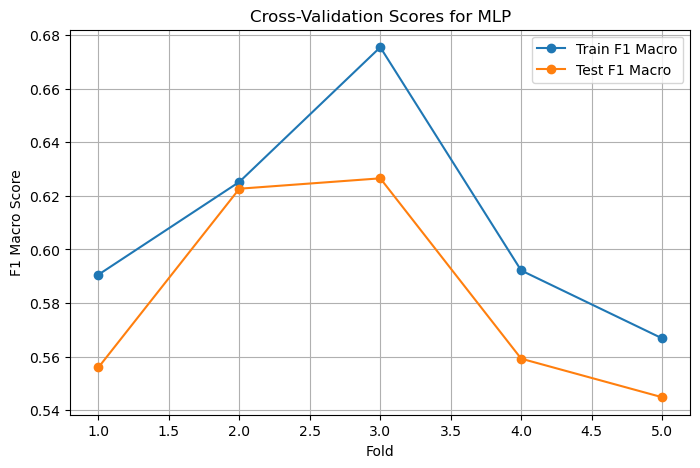

In [89]:
fig_b

In [90]:
#if True:
    # import seaborn as sns

    # sns.set(style="whitegrid")
    # sns.set_palette("magma")

    # fig, axs = plt.subplots(1, 3, figsize=(25, 6))

    # rs = {
    #     "DecisionTree": DecisionTreeRegressor(random_state=random_state),
    # }


    # for (n, r), ax in zip(rs.items(), axs.ravel()):
    #     r.fit(X_reg_train, y_reg_train)
    #     bee = r.predict(X_reg_test)

    #     mse = mean_squared_error(y_reg_test, bee)
    #     r2 = r2_score(y_reg_test, bee)
        
        
    #     ax.set_title(n, fontsize=35)
    #     ax.set_ylabel("Predicted Values", fontsize=30)
    #     ax.set_xlabel("Actual Values", fontsize=30)

    #     sns.scatterplot(x=y_reg_test, y=bee, ax=ax, s=50, alpha=0.7)
    #     ax.plot([min(y_reg_test), max(y_reg_test)], [min(bee), max(bee)], color='red', linestyle='--')

    #     ax.text(0.05, 0.95, f"MSE: {mse:.4f}\nR²: {r2:.4f}", transform=ax.transAxes, fontsize=26,
    #             verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white'))

    #     ax.tick_params(axis='both', which='major', labelsize=26)
    #     ax.tick_params(axis='both', which='minor', labelsize=26)

    # plt.tight_layout()
    # plt.show()

    # palette = sns.color_palette("magma", 6)
    # dot_color = palette

    # for i,ax in enumerate(axs):
    #     for line in ax.get_lines():
    #         line.set_color(dot_color[i])